<a href="https://colab.research.google.com/github/JACKARPANJACK/AI-Lab-6th-sem/blob/main/Normal_Hill_Climbing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Best solution: 1.9985275542473382
Best value: 3.9999978319035057


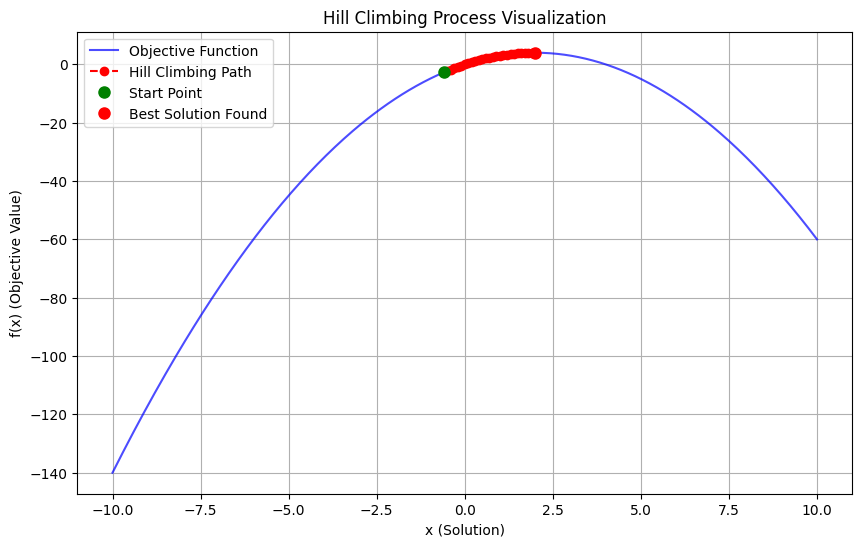

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np

def objective_function(x):
    # Example objective function: f(x) = -x**2 + 4*x
    return -x**2 + 4*x

def hill_climbing():
    # Initialize a random solution
    current_solution = random.uniform(-10, 10)
    current_value = objective_function(current_solution)

    step_size = 0.1
    max_iterations = 1000

    # Store the path for visualization
    solution_history = [current_solution]
    value_history = [current_value]

    for _ in range(max_iterations):
        # Generate neighbors
        neighbors = [current_solution + step_size, current_solution - step_size]

        # Evaluate neighbors
        next_solution_candidate = max(neighbors, key=objective_function)
        next_value_candidate = objective_function(next_solution_candidate)

        # Check if the neighbor is better
        if next_value_candidate > current_value:
            current_solution = next_solution_candidate
            current_value = next_value_candidate
            solution_history.append(current_solution)
            value_history.append(current_value)
        else:
            # If no better neighbors, return current solution
            break

    return current_solution, current_value, solution_history, value_history

def steepest_ascent_hill_climbing():
    # Steepest-Ascent Hill Climbing checks all neighbors and moves to the best one.
    current_solution = random.uniform(-10, 10)
    current_value = objective_function(current_solution)

    step_size = 0.1
    max_iterations = 1000

    for _ in range(max_iterations):
        # Generate all neighbors
        neighbors = [current_solution + step_size, current_solution - step_size]

        # Find the best neighbor
        next_solution = max(neighbors, key=objective_function)
        next_value = objective_function(next_solution)

        # If the best neighbor is better than current, move there
        if next_value > current_value:
            current_solution = next_solution
            current_value = next_value
            solution_history.append(current_solution)
            value_history.append(current_value)
        else:
            # If no neighbor is better, we are at a peak
            break

    return current_solution, current_value, solution_history, value_history

def stochastic_hill_climbing():
    # Stochastic Hill Climbing selects a neighbor at random and moves to it if it is better.
    current_solution = random.uniform(-10, 10)
    current_value = objective_function(current_solution)

    step_size = 0.1
    max_iterations = 1000

    for _ in range(max_iterations):
        # Pick ONE random neighbor
        neighbor = current_solution + random.choice([-step_size, step_size])
        neighbor_value = objective_function(neighbor)

        # If the neighbor is better, move there
        if neighbor_value > current_value:
            current_solution = neighbor
            current_value = neighbor_value
            solution_history.append(current_solution)
            value_history.append(current_value)

    return current_solution, current_value ,solution_history, value_history

def random_restart_hill_climbing():
    # Random-Restart Hill Climbing runs the algorithm multiple times from different
    # initial states and returns the best solution found.
    best_overall_solution = None
    best_overall_value = float("-inf")
    num_restarts = 100

    for _ in range(num_restarts):
        # Perform a single hill climbing run
        current_solution, current_value = steepest_ascent_hill_climbing()

        if current_value > best_overall_value:
            best_overall_value = current_value
            best_overall_solution = current_solution
            solution_history.append(current_solution)
            value_history.append(current_value)

    return best_overall_solution, best_overall_value ,solution_history, value_history

# Example usage
best_solution, best_value, solution_history, value_history = hill_climbing()
print(f"Best solution: {best_solution}")
print(f"Best value: {best_value}")

# Plotting the process
plt.figure(figsize=(10, 6))

# Plot the objective function
x_vals = np.linspace(-10, 10, 400)
y_vals = objective_function(x_vals)
plt.plot(x_vals, y_vals, label='Objective Function', color='blue', alpha=0.7)

# Plot the hill climbing path
plt.plot(solution_history, value_history, marker='o', linestyle='--', color='red', label='Hill Climbing Path')

# Mark the starting point and the best solution found
plt.plot(solution_history[0], value_history[0], 'go', markersize=8, label='Start Point')
plt.plot(best_solution, best_value, 'ro', markersize=8, label='Best Solution Found')

plt.title('Hill Climbing Process Visualization')
plt.xlabel('x (Solution)')
plt.ylabel('f(x) (Objective Value)')
plt.grid(True)
plt.legend()
plt.show()